In [1]:
from pathlib import Path
PROJECT_ROOT = Path.cwd().parents[1]
DATASET_DIR = PROJECT_ROOT/"Dataset"
MODEL_DIR = PROJECT_ROOT/"models"
IR_DIR = PROJECT_ROOT/"Pz and Sz"
FIG_DIR = PROJECT_ROOT/"figs"
print(PROJECT_ROOT)
print(DATASET_DIR)
print(MODEL_DIR)
print(FIG_DIR)
# Folder_name_list_of_dataset = ['Synthesized_Dataset/Training_data', 'Synthesized_Dataset/Validate_data', 'Synthesized_Dataset/Testing_data']
# Folder_name_list_of_dataset = [DATASET_DIR/i for i in Folder_name_list_of_dataset]
# File_sheet = "Hard_Index.csv"
# MODEL_PTH = MODEL_DIR/"M6_res_Synthetic.pth"

/home/rkobayashi/anc/GFANC-custom
/home/rkobayashi/anc/GFANC-custom/Dataset
/home/rkobayashi/anc/GFANC-custom/models
/home/rkobayashi/anc/GFANC-custom/figs


In [2]:
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [3]:

import matplotlib.pyplot as plt
import numpy as np
import torch

from common.loading_real_wave_noise import loading_real_wave_noise
from common.Reading_path_test import loading_paths_from_MAT
from data.Disturbance_generation import Disturbance_generation_from_real_noise
from fxlms.FxLMS_algorithm_v2 import FxLMS, train_fxlms_algorithm
from gfanc.Control_filter_selection_pre_now import Control_filter_selection_pre_now
from gfanc.Fixed_filter_noise_cancellation_subfilters import Fixed_filter_controller

print(torch.cuda.is_available())

True


In [4]:
# Loading real noises
mdict = {}
fs = 16000
StepSize = 0.0001
sound_name = 'Helicopter'
waveform, resample_rate = loading_real_wave_noise(folde_name=PROJECT_ROOT/'Real Noise Examples/', sound_name=sound_name+'.wav')
waveform = waveform[0].unsqueeze(0)

In [30]:
delay = -25
# Loading path
subfolder = "Secondary_path_delay_" + str(delay) + "samples"
Pri_path, Secon_path = loading_paths_from_MAT(folder=IR_DIR, subfolder=subfolder, Pri_path_file_name='Primary_path.mat', Sec_path_file_name='Secondary_path.mat')
Dis, Fx, Re = Disturbance_generation_from_real_noise(fs=fs, Repet=0, wave_form=waveform, Pri_path=Pri_path, Sec_path=Secon_path)
# Dis: disturbance (cotrolled noise)， Fx: fixed-x signal, Re: repeated waveform (primary_noise) Repetition=Repet+1print(waveform.shape)
print(Dis.shape, Fx.shape, Re.shape)
import matplotlib as mpl
mpl.rcParams['agg.path.chunksize'] = 10000

torch.Size([160000]) torch.Size([160000]) torch.Size([160000])


In [32]:
ErrorFixeds = {}
ErrorFxLMSs = {}

In [34]:
delays = [-25, 0, 5]
for delay in delays:
    # Loading path
    subfolder = "Secondary_path_delay_" + str(delay) + "samples"
    Pri_path, Secon_path = loading_paths_from_MAT(folder=IR_DIR, subfolder=subfolder, Pri_path_file_name='Primary_path.mat', Sec_path_file_name='Secondary_path.mat')
    Dis, Fx, Re = Disturbance_generation_from_real_noise(fs=fs, Repet=0, wave_form=waveform, Pri_path=Pri_path, Sec_path=Secon_path)
    # GFANC: combining previous and present frame to predict the next
    print(f"delay: {delay}")
    MODEL_PTH = MODEL_DIR/"M6_res_Synthetic.pth"
    subfilters = "Pretrained_Sub_Control_filters_delay_" + str(delay) + ".mat"
    fig_name = sound_name+"_delay_" + str(delay) + "GFANC.png"
    path_mat = MODEL_DIR/subfilters

    Filter_vector = Control_filter_selection_pre_now(fs=16000, MODEL_PTH=MODEL_PTH, path_mat=path_mat, Primary_noise=Re.unsqueeze(0), threshold=0.5)

    Fixed_Cancellation = Fixed_filter_controller(Filter_vector=Filter_vector, fs=16000)
    ErrorFixed = Fixed_Cancellation.noise_cancellation(Dis=Dis, Fx=Fx)

    Time = np.arange(len(Dis))*(1/fs)
    # plt.rc('font', size=18, family='Times New Roman') # 将plt画图时字号设置为9字体设置为Times New Roman
    # plt.rc('axes', titlesize=18) # fontsize of the axes title
    # plt.rc('axes', labelsize=18) # fontsize of the x and y labels
    # plt.rc('xtick', labelsize=18) # fontsize of the tick labels
    # plt.rc('ytick', labelsize=18) # fontsize of the tick labels
    # plt.rc('legend', fontsize=15) # legend fontsize
    # plt.rc('figure', titlesize=18) # fontsize of the figure title

    # plt.title('The GFANC Algorithm')
    # plt.plot(Time, Dis, color='blue', label='ANC off')
    # plt.plot(Time, ErrorFixed, color='orange', label='ANC on')
    # plt.ylabel('Magnitude')
    # plt.xlabel('Time (seconds)')
    # plt.legend()
    # plt.grid()
    # plt.savefig(FIG_DIR/fig_name, dpi=600, bbox_inches='tight', pad_inches=0)
    # plt.show()
    ErrorFixeds[delay] = 10*torch.log10(ErrorFixed.square().mean()/Dis.square().mean())
print(ErrorFixeds)

delay: -25
/home/rkobayashi/anc/GFANC-custom/models/Pretrained_Sub_Control_filters_delay_-25.mat
The primary nosie has 10 seconds !!!
1 [1 1 1 0 0 0 0 0 0 0 0 0 0 0 0]
2 [1 1 1 0 0 0 0 0 0 0 0 0 0 0 0]
3 [1 1 1 0 0 0 0 0 0 0 0 0 0 0 0]
4 [1 1 1 0 0 0 0 0 0 0 0 0 0 0 0]
5 [1 1 1 0 0 0 0 0 0 0 0 0 0 0 0]
6 [1 1 1 0 0 0 0 0 0 0 0 0 0 0 0]
7 [1 1 1 0 0 0 0 0 0 0 0 0 0 0 0]
8 [1 1 1 0 0 0 0 0 0 0 0 0 0 0 0]
9 [1 1 1 0 0 0 0 0 0 0 0 0 0 0 0]
10 [1 1 1 0 0 0 0 0 0 0 0 0 0 0 0]
delay: 0
/home/rkobayashi/anc/GFANC-custom/models/Pretrained_Sub_Control_filters_delay_0.mat
The primary nosie has 10 seconds !!!
1 [1 1 1 0 0 0 0 0 0 0 0 0 0 0 0]
2 [1 1 1 0 0 0 0 0 0 0 0 0 0 0 0]
3 [1 1 1 0 0 0 0 0 0 0 0 0 0 0 0]
4 [1 1 1 0 0 0 0 0 0 0 0 0 0 0 0]
5 [1 1 1 0 0 0 0 0 0 0 0 0 0 0 0]
6 [1 1 1 0 0 0 0 0 0 0 0 0 0 0 0]
7 [1 1 1 0 0 0 0 0 0 0 0 0 0 0 0]
8 [1 1 1 0 0 0 0 0 0 0 0 0 0 0 0]
9 [1 1 1 0 0 0 0 0 0 0 0 0 0 0 0]
10 [1 1 1 0 0 0 0 0 0 0 0 0 0 0 0]
delay: 5
/home/rkobayashi/anc/GFANC-custom/models/Pret

In [51]:
ErrorFxLMSs

{0.0001: {-25: tensor(-4.4555), 0: tensor(-3.1107), 5: tensor(-1.9762)},
 0.001: {-25: tensor(-10.2359), 0: tensor(-7.8332), 5: tensor(-4.0447)},
 0.01: {-25: tensor(-16.3391), 0: tensor(-14.0915), 5: tensor(-6.1405)},
 0.1: {-25: tensor(-22.1160), 0: tensor(-20.9195), 5: tensor(-9.9025)},
 1.0: {-25: tensor(nan), 0: tensor(nan), 5: tensor(nan)}}

In [41]:
# FxLMS
delays = [-25, 0, 5]
StepSizes = [ StepSize * 10 ** i for i in range(5)]
for stepsize in StepSizes:
    ErrorTemp = {}
    for delay in delays:
        # Loading path
        subfolder = "Secondary_path_delay_" + str(delay) + "samples"
        Pri_path, Secon_path = loading_paths_from_MAT(folder=IR_DIR, subfolder=subfolder, Pri_path_file_name='Primary_path.mat', Sec_path_file_name='Secondary_path.mat')
        Dis, Fx, Re = Disturbance_generation_from_real_noise(fs=fs, Repet=0, wave_form=waveform, Pri_path=Pri_path, Sec_path=Secon_path)
        # GFANC: combining previous and present frame to predict the next
        print(f"delay: {delay}")
        controller = FxLMS(Len=1024) # 1024 is the same size of coeffient vector of fixed-filter
        ErrorFxLMS = train_fxlms_algorithm(Model=controller, Ref=Fx, Disturbance=Dis, Stepsize=stepsize) # torch.Size([320000])
        ErrorTemp[delay] = 10*torch.log10(torch.tensor(ErrorFxLMS).square().mean()/Dis.square().mean())
    ErrorFxLMSs[stepsize] = ErrorTemp
print(ErrorFxLMSs)
# Time = np.arange(len(Dis))*(1/fs)
# plt.title('The FxLMS Algorithm')
# plt.plot(Time, Dis, color='blue', label='ANC off')
# plt.plot(Time, ErrorFxLMS, color='green', label='ANC on')
# plt.ylabel('Magnitude')
# plt.xlabel('Time (seconds)')
# plt.legend()
# plt.grid()
# plt.savefig(FIG_DIR/(sound_name + 'FxLMS.png'), dpi=600, bbox_inches='tight', pad_inches=0)
# plt.show()

delay: -25


[========================================================================] 100%


delay: 0


[========================================================================] 100%


delay: 5


...

delay: 0


[========================================================================] 100%


delay: 5


{0.0001: {-25: tensor(-4.4555), 0: tensor(-3.1107), 5: tensor(-1.9762)}, 0.001: {-25: tensor(-10.2359), 0: tensor(-7.8332), 5: tensor(-4.0447)}, 0.01: {-25: tensor(-16.3391), 0: tensor(-14.0915), 5: tensor(-6.1405)}, 0.1: {-25: tensor(-22.1160), 0: tensor(-20.9195), 5: tensor(-9.9025)}, 1.0: {-25: tensor(nan), 0: tensor(nan), 5: tensor(nan)}}


[========================================================================] 100%


In [50]:
# FxLMS
delays = [-25, 0, 5]
StepSizes = [ StepSize * 10 ** i for i in range(5)]
whitenoise = torch.randn(fs, dtype=torch.float32).unsqueeze(0) * waveform.var().sqrt()
for stepsize in StepSizes:
    ErrorTemp = {}
    for delay in delays:
        # Loading path
        subfolder = "Secondary_path_delay_" + str(delay) + "samples"
        Pri_path, Secon_path = loading_paths_from_MAT(folder=IR_DIR, subfolder=subfolder, Pri_path_file_name='Primary_path.mat', Sec_path_file_name='Secondary_path.mat')
        Dis, Fx, Re = Disturbance_generation_from_real_noise(fs=fs, Repet=0, wave_form=whitenoise, Pri_path=Pri_path, Sec_path=Secon_path)
        # GFANC: combining previous and present frame to predict the next
        print(f"delay: {delay}")
        controller = FxLMS(Len=1024) # 1024 is the same size of coeffient vector of fixed-filter
        ErrorFxLMS = train_fxlms_algorithm(Model=controller, Ref=Fx, Disturbance=Dis, Stepsize=stepsize) # torch.Size([320000])
        ErrorTemp[delay] = 10*torch.log10(torch.tensor(ErrorFxLMS).square().mean()/Dis.square().mean())
    print(ErrorTemp)
# Time = np.arange(len(Dis))*(1/fs)
# plt.title('The FxLMS Algorithm')
# plt.plot(Time, Dis, color='blue', label='ANC off')
# plt.plot(Time, ErrorFxLMS, color='green', label='ANC on')
# plt.ylabel('Magnitude')
# plt.xlabel('Time (seconds)')
# plt.legend()
# plt.grid()
# plt.savefig(FIG_DIR/(sound_name + 'FxLMS.png'), dpi=600, bbox_inches='tight', pad_inches=0)
# plt.show()

delay: -25


[========================================================================] 100%


delay: 0


[========================================================================] 100%


delay: 5


...

delay: 0


[========================================================================] 100%


delay: 5


{-25: tensor(nan), 0: tensor(nan), 5: tensor(nan)}


[========================================================================] 100%


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

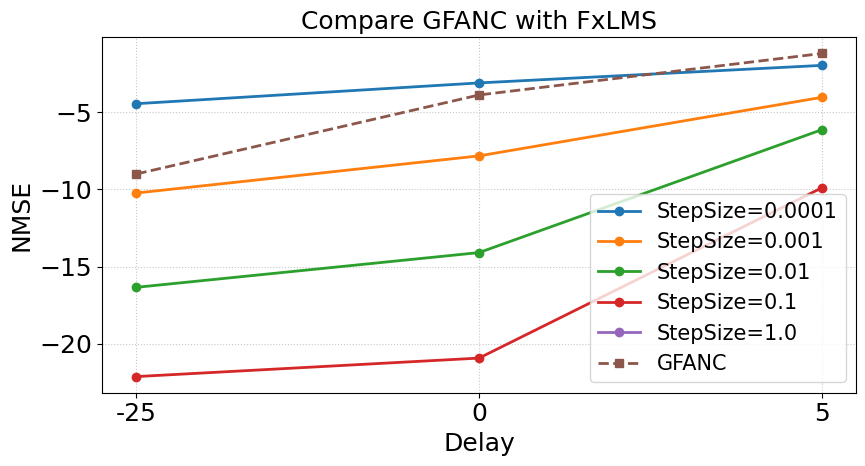

In [57]:
fig, ax = plt.subplots(figsize=(9, 5))

# 横軸の位置を等間隔にする
delays = [-25, 0, 5]
x_positions = range(len(delays))

for param, values in ErrorFxLMSs.items():
    y = [float(values[d]) if d in values else float("nan")
         for d in delays]

    ax.plot(
        x_positions[:len(delays)],
        y,
        marker="o",
        linewidth=2,
        label=f"StepSize={param}",
    )

# GFANC
y = [float(ErrorFixeds[d]) for d in delays]

ax.plot(
    x_positions,
    y,
    marker="s",
    linestyle="--",
    linewidth=2,
    label="GFANC",
)

ax.set_xlabel("Delay")
ax.set_ylabel("NMSE")
ax.set_title("Compare GFANC with FxLMS")

# 等間隔の位置に元の遅延値を表示
ax.set_xticks(list(x_positions))
ax.set_xticklabels(delays)

ax.grid(True, linestyle=":", alpha=0.7)
ax.legend()
fig.tight_layout()
plt.show()

In [ ]:
# compare the Noise_Reduction_Level in every second

def Noise_Reduction_Level_Compute(Disturbance, Error):
    Power_dis = 10*np.log10(np.var(Disturbance))
    Power_err = 10*np.log10(np.var(Error))
    NR_level = Power_dis - Power_err
    return NR_level

if torch.is_tensor(Dis):
    Dis = Dis.numpy() # tensor to numpy
if torch.is_tensor(ErrorFixed):
    ErrorFixed = ErrorFixed.numpy()
# if torch.is_tensor(ErrorFixed2):
#     ErrorFixed2 = ErrorFixed2.numpy()

a, b, c, d = [], [], [], []
a.append(Dis[0])
b.append(Dis[0])
c.append(Dis[0])
d.append(Dis[0])
Time1 = int(len(Dis)/fs)
for t in range(Time1):
    a.append(Noise_Reduction_Level_Compute(Dis[t*fs:(t+1)*fs], ErrorFixed[t*fs:(t+1)*fs]))
    # b.append(Noise_Reduction_Level_Compute(Dis[t*fs:(t+1)*fs], Error_SFANC_FxNLMS[t*fs:(t+1)*fs]))
    c.append(Noise_Reduction_Level_Compute(Dis[t*fs:(t+1)*fs], ErrorFxLMS[t*fs:(t+1)*fs]))
    # d.append(Noise_Reduction_Level_Compute(Dis[t*fs:(t+1)*fs], Error_SFANC_FxNLMS_[t*fs:(t+1)*fs]))
    
plt.title('(d) Averaged Noise Reduction Level of Every 1s')

plt.step(range(Time1+1), c, color='green', label='FxLMS')
# plt.step(range(0,Time1+1), b, color='blue', label='SFANC')
# plt.step(range(0,Time1+1), d, color="purple", label="SFANC-FxLMS")
plt.step(range(Time1+1), a, color='red', label='GFANC')
plt.ylabel('Noise Reduction Level (dB)')
plt.xlabel('Time (seconds)')
plt.xticks(range(0, Time1+1, 2)) # the interval in x
plt.legend()
plt.grid()
plt.savefig('Noise_Reduction_Level_Aircraft_Traffic_mix.png', dpi=600, bbox_inches='tight', pad_inches=0)
plt.show()

NameError: name 'ErrorFxLMS' is not defined

In [ ]:
def plot_specgram(waveform, sample_rate, filepath, title="Spectrogram", xlim=None):
    waveform = waveform.numpy()

    num_channels, num_frames = waveform.shape
    time_axis = torch.arange(0, num_frames) / sample_rate

    figure, axes = plt.subplots(num_channels, 1)
    if num_channels == 1:
        axes = [axes]
    for c in range(num_channels):
        axes[c].specgram(waveform[c], Fs=sample_rate)
        if num_channels > 1:
            axes[c].set_ylabel(f'Channel {c+1}')
        if xlim:
            axes[c].set_xlim(xlim)
    figure.suptitle(title)
    plt.savefig(filepath)
    plt.close('all')

In [ ]:
spec_dis = torch.tensor(ErrorFixed).unsqueeze(0)
filepath = "spec/" + sound_name
plot_specgram(spec_dis, sample_rate=fs, filepath=filepath, title=("Spectrogram err "+ sound_name))

/tmp/ipykernel_1130819/2423939123.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  spec_dis = torch.tensor(ErrorFixed).unsqueeze(0)
